# Módulo 4 - Análise Exploratória de Dados (EDA)

Bem-vindo ao **Módulo 4: Análise Exploratória de Dados**.

Este módulo é o ponto de união de tudo o que você aprendeu até aqui:
- **Módulo 1**: Python básico
- **Módulo 2**: Manipulação de dados com Pandas
- **Módulo 3**: Visualização com Matplotlib e Seaborn

Agora você vai usar tudo isso para **investigar um problema real** com dados reais.

> **O que é EDA?**
> EDA (Exploratory Data Analysis) é o processo de explorar um dataset para entender sua estrutura, identificar padrões, detectar anomalias e gerar hipóteses antes de tirar conclusões.

---

**Dataset utilizado:** Atlas do Desenvolvimento Humano dos Municípios Brasileiros (1991-2010)

**Fonte:** Atlas Brasil / Base dos Dados

### 1. Objetivos do módulo

- Entender o que é e quando usar Análise Exploratória de Dados (EDA)
- Aprender a identificar padrões e relações entre variáveis
- Explorar indicadores socioeconômicos do Brasil e de seus municípios
- Gerar insights relevantes para decisões e políticas públicas


### 1.1 O que você vai aprender

- Fazer a análise de um dataset real do Brasil
- Realizar limpeza de dados e identificar valores ausentes
- Criar visualizações claras e eficazes para comunicar resultados
- Entender a relação entre desenvolvimento humano, educação, renda e desigualdade
- Construir uma narrativa de dados para apoiar conclusões e recomendações


### 2. Descrição do dataset

O dataset reúne informações dos municípios brasileiros entre 1991 e 2010.

Ele inclui dados socioeconômicos, demográficos e de desenvolvimento humano, como renda, desigualdade, educação, expectativa de vida e acesso a serviços básicos.

O objetivo é entender como esses indicadores se relacionam com o IDHM e como as diferentes regiões do país evoluíram ao longo do tempo.

## 4. Importando bibliotecas e carregando os dados

In [10]:
# Importando as bibliotecas necessarias
import pandas as pd           # manipulacao de dados
import numpy as np            # calculos numericos
import matplotlib.pyplot as plt  # graficos base
import seaborn as sns          # graficos de alto nivel
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")  # suprime avisos tecnicos

# Configuracoes visuais
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [11]:
# Caminhos possiveis para os datasets
caminhos_adh = [
    "../../eda/indices_adh_municipio.csv",
    "../eda/indices_adh_municipio.csv",
    "indices_adh_municipio.csv",
    "eda/indices_adh_municipio.csv",
]

caminhos_mun = [
    "../../eda/identificador_municipios.csv",
    "../eda/identificador_municipios.csv",
    "identificador_municipios.csv",
    "eda/identificador_municipios.csv",
]

# Carregando o dataset principal (ADH)
df_adh = None
for c in caminhos_adh:
    if Path(c).exists():
        # Carrega apenas as colunas que vamos usar (economiza memoria)
        colunas_adh = [
            "ano", "id_municipio",
            "idhm", "idhm_e", "idhm_r", "idhm_l",
            "renda_pc", "indice_gini",
            "expectativa_anos_estudo", "taxa_analfabetismo_15_mais",
            "expectativa_vida", "prop_pobreza",
            "taxa_agua_encanada", "taxa_energia_eletrica",
            "populacao"
        ]
        df_adh = pd.read_csv(c, usecols=lambda x: x in colunas_adh)
        print(f"ADH carregado de: {c}")
        print(f"Dimensao: {df_adh.shape[0]} linhas x {df_adh.shape[1]} colunas")
        break

# Carregando o dataset de identificação dos municípios
df_mun = None
for c in caminhos_mun:
    if Path(c).exists():
        df_mun = pd.read_csv(c, usecols=["id_municipio", "nome", "sigla_uf", "nome_regiao"])
        print(f"Municípios carregado de: {c}")
        print(f"Dimensao: {df_mun.shape[0]} linhas x {df_mun.shape[1]} colunas")
        break

if df_adh is None or df_mun is None:
    print("ATENÇÃO: Um ou mais datasets não foram encontrados.")
    print("Verifique se os arquivos estao na pasta 'eda/'.")

ADH carregado de: ../../eda/indices_adh_municipio.csv
Dimensao: 16695 linhas x 15 colunas
Municípios carregado de: ../../eda/identificador_municipios.csv
Dimensao: 5571 linhas x 4 colunas


In [12]:
# Unindo os dois datasets
# Usamos o 'id_municipio' como chave de ligacao (como um CPF do municipio)
if df_adh is not None and df_mun is not None:

    df = df_adh.merge(
        df_mun,                   # dataset com os nomes dos municipios
        on="id_municipio",        # coluna em comum
        how="left"                # mantemos todos os registros do ADH
    )

    print(f"Dataset unificado: {df.shape[0]} linhas x {df.shape[1]} colunas")
    print(f"Anos disponíveis: {sorted(df['ano'].unique())}")
    print(f"Regiões: {df['nome_regiao'].dropna().unique()}")
    df.head()

Dataset unificado: 16695 linhas x 18 colunas
Anos disponíveis: [np.int64(1991), np.int64(2000), np.int64(2010)]
Regiões: ['Norte' 'Nordeste' 'Sudeste' 'Sul' 'Centro-Oeste']


## 5. Limpeza e preparação dos dados

Antes de qualquer análise, precisamos entender e tratar a qualidade dos dados.

Este passo é crítico: dados sujos geram conclusões erradas.


In [13]:
if df is not None:
    # 5.1 Verificando o formato dos dados
    print("=== TIPOS DE DADOS ===")
    print(df.dtypes)
    print()

    # 5.2 Dimensão por ano
    print("=== REGISTROS POR ANO ===")
    print(df.groupby("ano").size())

=== TIPOS DE DADOS ===
ano                             int64
id_municipio                    int64
expectativa_vida              float64
expectativa_anos_estudo       float64
taxa_analfabetismo_15_mais    float64
indice_gini                   float64
prop_pobreza                  float64
renda_pc                      float64
taxa_agua_encanada            float64
taxa_energia_eletrica         float64
populacao                       int64
idhm                          float64
idhm_e                        float64
idhm_l                        float64
idhm_r                        float64
nome                           object
sigla_uf                       object
nome_regiao                    object
dtype: object

=== REGISTROS POR ANO ===
ano
1991    5565
2000    5565
2010    5565
dtype: int64


In [14]:
if df is not None:
    # 5.3 Verificando valores ausentes
    nulos = df.isnull().sum()
    nulos_percent = (nulos / len(df) * 100).round(2)

    resumo_nulos = pd.DataFrame({
        "Valores Nulos": nulos,
        "Percentual (%)": nulos_percent
    })

    # Mostra apenas colunas COM valores nulos
    resumo_nulos_filtrado = resumo_nulos[resumo_nulos["Valores Nulos"] > 0].sort_values("Percentual (%)", ascending=False)

    if len(resumo_nulos_filtrado) > 0:
        print("=== COLUNAS COM VALORES NULOS ===")
        print(resumo_nulos_filtrado)
    else:
        print("Não há valores nulos no dataset!")

Não há valores nulos no dataset!


In [15]:
if df is not None:
    # 5.4 Tratamento dos valores ausentes

    # Identificamos as colunas numericas do nosso dataset
    colunas_numericas = ["idhm", "idhm_e", "idhm_r", "idhm_l", "renda_pc",
                         "indice_gini", "expectativa_anos_estudo",
                         "taxa_analfabetismo_15_mais", "expectativa_vida",
                         "prop_pobreza", "taxa_agua_encanada",
                         "taxa_energia_eletrica", "populacao"]

    # Para cada coluna numerica: preenchemos nulos com a mediana do mesmo ANO
    # (mediana e mais robusta que media quando ha outliers)
    for col in colunas_numericas:
        if col in df.columns:
            # Preenche com a mediana dentro de cada ano
            df[col] = df.groupby("ano")[col].transform(
                lambda x: x.fillna(x.median())
            )

    # 5.5 Remove linhas que ainda tem IDHM nulo (sao muito poucas)
    df = df.dropna(subset=["idhm"])

    print(f"Dataset apos limpeza: {df.shape[0]} linhas")
    print(f"Valores nulos restantes em 'idhm': {df['idhm'].isnull().sum()}")

Dataset apos limpeza: 16695 linhas
Valores nulos restantes em 'idhm': 0


In [16]:
if df is not None:
    # 5.6 Verificando consistencia dos dados
    # Pergunta: os valores de IDHM estao dentro do intervalo esperado (0 a 1)?

    print("=== CONSISTENCIA DOS VALORES DE IDHM ===")
    print(f"Minimo: {df['idhm'].min():.3f}")
    print(f"Maximo: {df['idhm'].max():.3f}")
    print(f"Valores fora do intervalo [0,1]: {len(df[(df['idhm'] < 0) | (df['idhm'] > 1)])}")
    print()
    print("=== VALORES EXTREMOS DE RENDA PER CAPITA ===")
    if "renda_pc" in df.columns:
        print(df["renda_pc"].describe())

=== CONSISTENCIA DOS VALORES DE IDHM ===
Minimo: 0.120
Maximo: 0.862
Valores fora do intervalo [0,1]: 0

=== VALORES EXTREMOS DE RENDA PER CAPITA ===
count   16695.000
mean      355.660
std       224.157
min        33.240
25%       182.105
50%       299.380
75%       487.240
max      2043.740
Name: renda_pc, dtype: float64


## 6. Análise Exploratória

Agora começa a parte mais interessante. Vamos responder as perguntas norteadoras uma a uma, usando estatisticas e graficos.

### 6.1 Como o IDHM evoluiu entre 1991 e 2010?

Vamos comecar pela pergunta mais ampla: o Brasil melhorou ao longo do tempo?

In [17]:
if df is not None:
    # Calcula o IDHM médio por ano
    idhm_por_ano = df.groupby("ano")["idhm"].agg(["mean", "median", "std"]).reset_index()
    idhm_por_ano.columns = ["Ano", "Média", "Mediana", "Desvio Padrão"]

    print("=== IDHM MÉDIO POR ANO ===")
    print(idhm_por_ano.to_string(index=False))

    # Calcula a variação percentual
    idhm_1991 = idhm_por_ano.loc[idhm_por_ano["Ano"]==1991, "Média"].values[0]
    idhm_2010 = idhm_por_ano.loc[idhm_por_ano["Ano"]==2010, "Média"].values[0]
    variacao = (idhm_2010 - idhm_1991) / idhm_1991 * 100

    print(f"\nVariação do IDHM médio de 1991 a 2010: +{variacao:.1f}%")

=== IDHM MÉDIO POR ANO ===
 Ano  Média  Mediana  Desvio Padrão
1991  0.381    0.382          0.103
2000  0.523    0.533          0.104
2010  0.659    0.665          0.072

Variação do IDHM médio de 1991 a 2010: +72.8%


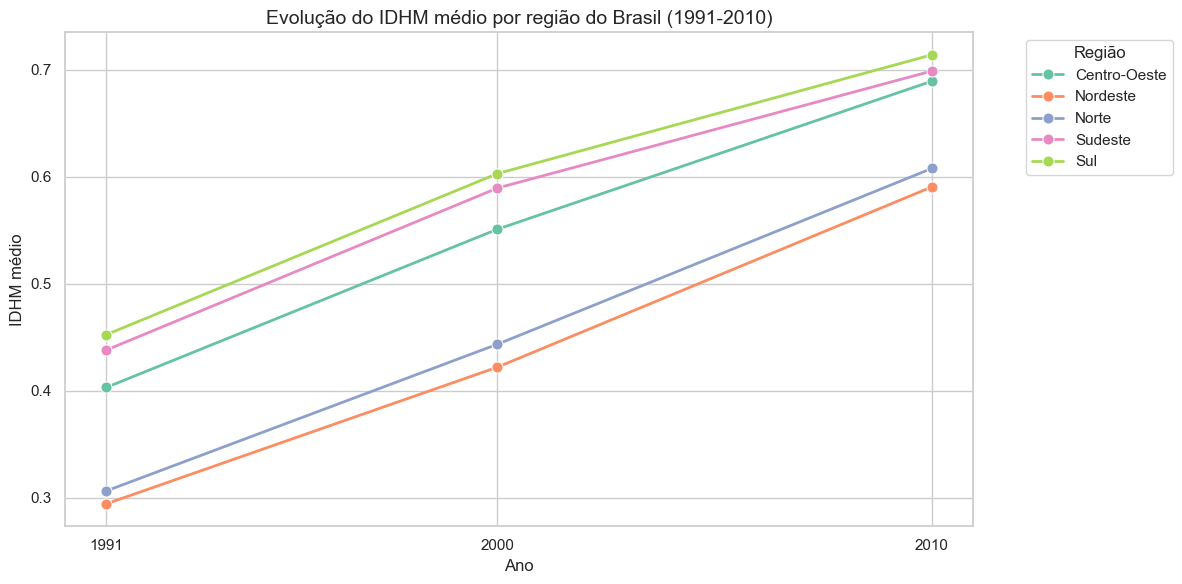

In [18]:
if df is not None:
    # Gráfico: evolução do IDHM por região
    idhm_regiao_ano = df.groupby(["ano", "nome_regiao"]) ["idhm"].mean().reset_index()

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=idhm_regiao_ano,
        x="ano",
        y="idhm",
        hue="nome_regiao",
        marker="o",
        markersize=8,
        linewidth=2
    )

    plt.title("Evolução do IDHM médio por região do Brasil (1991-2010)", fontsize=14)
    plt.xlabel("Ano")
    plt.ylabel("IDHM médio")
    plt.xticks([1991, 2000, 2010])
    plt.legend(title="Região", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

### 6.2 Relação entre educação e desenvolvimento humano

A educação é considerada um dos pilares mais importantes do desenvolvimento. Vamos verificar isso nos dados.


In [19]:
if df is not None:
    # Foco em 2010 (dados mais recentes)
    df_2010 = df[df["ano"] == 2010].copy()

    # Estatísticas descritivas das variáveis de educação
    print("=== ESTATÍSTICAS - VARIÁVEIS DE EDUCAÇÃO (2010) ===")
    colunas_edu = [c for c in ["expectativa_anos_estudo", "taxa_analfabetismo_15_mais", "idhm_e"] if c in df_2010.columns]
    print(df_2010[colunas_edu].describe().round(3))

=== ESTATÍSTICAS - VARIÁVEIS DE EDUCAÇÃO (2010) ===
       expectativa_anos_estudo  taxa_analfabetismo_15_mais   idhm_e
count                 5565.000                    5565.000 5565.000
mean                     9.464                      16.159    0.559
std                      1.098                       9.840    0.093
min                      4.340                       0.950    0.207
25%                      8.750                       8.080    0.490
50%                      9.470                      13.120    0.560
75%                     10.210                      24.320    0.631
max                     12.830                      44.400    0.825


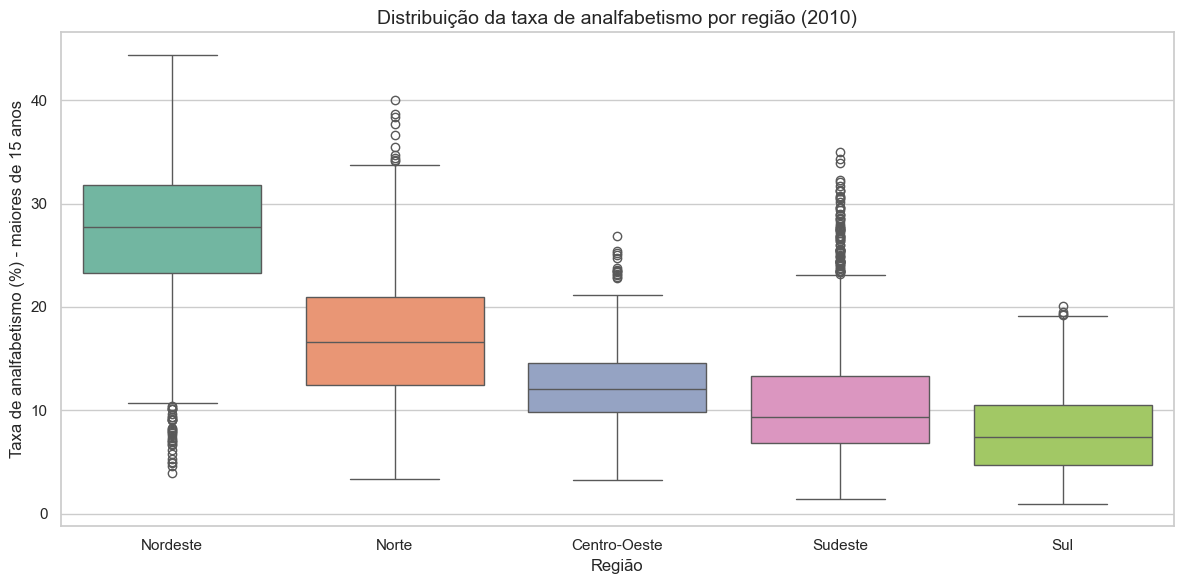


 Interpretação:
O Nordeste concentra as maiores taxas de analfabetismo.
A região Sul/Sudeste apresenta as menores taxas.
Esta desigualdade regional é um dos principais desafios educacionais do Brasil.


In [20]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()

    if "taxa_analfabetismo_15_mais" in df_2010.columns and "idhm" in df_2010.columns:

        # Distribuição da taxa de analfabetismo por região
        plt.figure(figsize=(12, 6))

        sns.boxplot(
            data=df_2010,
            x="nome_regiao",
            y="taxa_analfabetismo_15_mais",
            palette="Set2",
            order=df_2010.groupby("nome_regiao")["taxa_analfabetismo_15_mais"].median().sort_values(ascending=False).index
        )

        plt.title("Distribuição da taxa de analfabetismo por região (2010)", fontsize=14)
        plt.xlabel("Região")
        plt.ylabel("Taxa de analfabetismo (%) - maiores de 15 anos")
        plt.tight_layout()
        plt.show()

        print("\n Interpretação:")
        print("O Nordeste concentra as maiores taxas de analfabetismo.")
        print("A região Sul/Sudeste apresenta as menores taxas.")
        print("Esta desigualdade regional é um dos principais desafios educacionais do Brasil.")

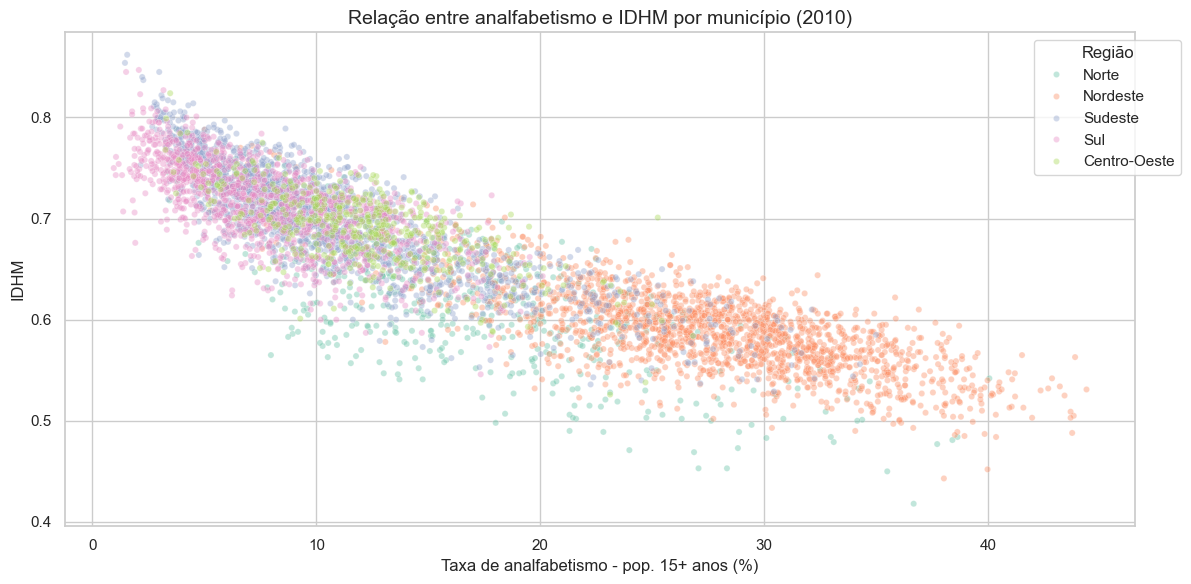


 Correlação entre analfabetismo e IDHM: -0.884
Interpretação: Correlação negativa forte.
Quanto maior o analfabetismo, menor o IDHM.


In [21]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()

    if "taxa_analfabetismo_15_mais" in df_2010.columns and "idhm" in df_2010.columns:

        plt.figure(figsize=(12, 6))

        sns.scatterplot(
            data=df_2010,
            x="taxa_analfabetismo_15_mais",
            y="idhm",
            hue="nome_regiao",
            alpha=0.4,
            palette="Set2",
            s=20
        )

        plt.title("Relação entre analfabetismo e IDHM por município (2010)", fontsize=14)
        plt.xlabel("Taxa de analfabetismo - pop. 15+ anos (%)")
        plt.ylabel("IDHM")
        plt.legend(title="Região", bbox_to_anchor=(1.05, 1))
        plt.tight_layout()
        plt.show()

        # Correlação
        corr = df_2010[["taxa_analfabetismo_15_mais", "idhm"]].corr().iloc[0,1]
        print(f"\n Correlação entre analfabetismo e IDHM: {corr:.3f}")
        print("Interpretação: Correlação negativa forte.")
        print("Quanto maior o analfabetismo, menor o IDHM.")

### 6.3 Renda, desigualdade e desenvolvimento

Como a renda e a desigualdade se relacionam com o IDHM?

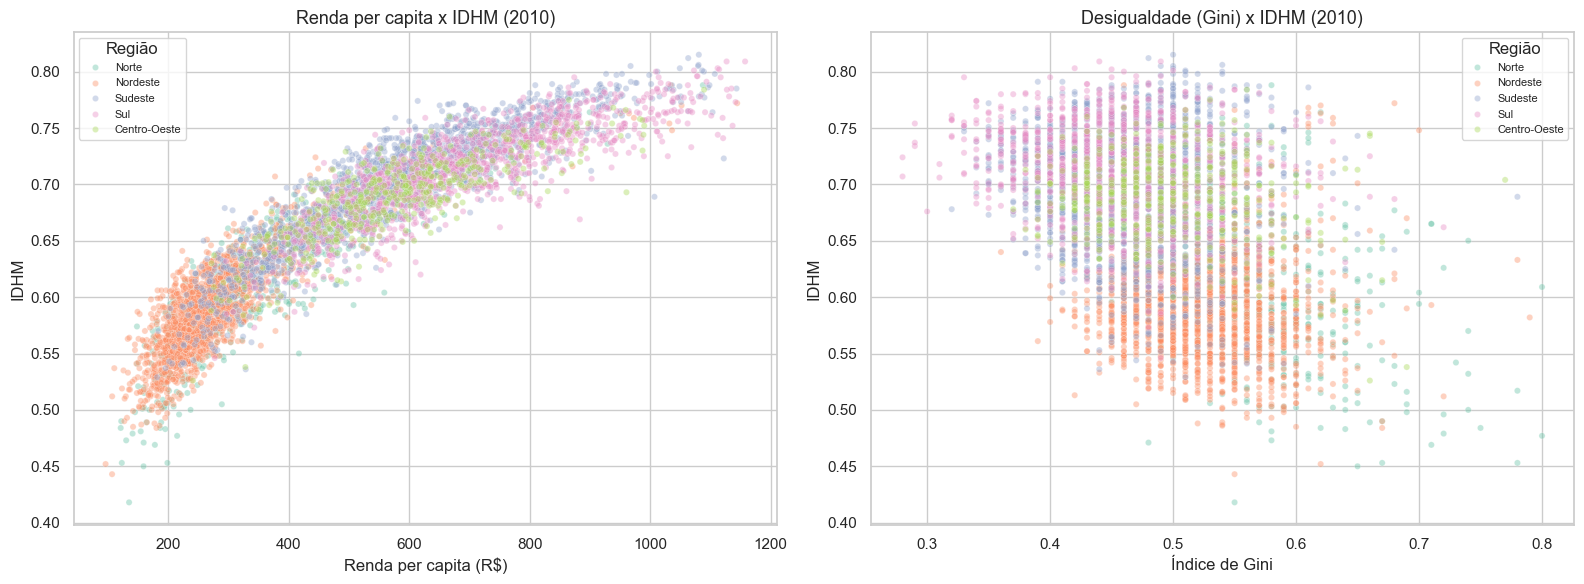


 Correlação entre renda per capita e IDHM: 0.922
 Correlação entre Gini e IDHM: -0.456

Interpretação:
- Renda e IDHM têm correlação positiva forte: mais renda = mais desenvolvimento
- Gini e IDHM têm correlação negativa: mais desigualdade = menos desenvolvimento


In [22]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()

    if "renda_pc" in df_2010.columns and "idhm" in df_2010.columns:

        # Remove outliers extremos de renda (top 1%)
        p99 = df_2010["renda_pc"].quantile(0.99)
        df_plot = df_2010[df_2010["renda_pc"] <= p99].copy()

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Gráfico 1: renda x IDHM
        sns.scatterplot(
            data=df_plot,
            x="renda_pc",
            y="idhm",
            hue="nome_regiao",
            alpha=0.4,
            palette="Set2",
            s=20,
            ax=axes[0]
        )
        axes[0].set_title("Renda per capita x IDHM (2010)", fontsize=13)
        axes[0].set_xlabel("Renda per capita (R$)")
        axes[0].set_ylabel("IDHM")
        axes[0].legend(title="Região", fontsize=8)

        # Gráfico 2: Gini x IDHM
        if "indice_gini" in df_plot.columns:
            sns.scatterplot(
                data=df_plot,
                x="indice_gini",
                y="idhm",
                hue="nome_regiao",
                alpha=0.4,
                palette="Set2",
                s=20,
                ax=axes[1]
            )
            axes[1].set_title("Desigualdade (Gini) x IDHM (2010)", fontsize=13)
            axes[1].set_xlabel("Índice de Gini")
            axes[1].set_ylabel("IDHM")
            axes[1].legend(title="Região", fontsize=8)

        plt.tight_layout()
        plt.show()

        corr_renda = df_plot[["renda_pc", "idhm"]].corr().iloc[0,1]
        print(f"\n Correlação entre renda per capita e IDHM: {corr_renda:.3f}")
        if "indice_gini" in df_plot.columns:
            corr_gini = df_plot[["indice_gini", "idhm"]].corr().iloc[0,1]
            print(f" Correlação entre Gini e IDHM: {corr_gini:.3f}")
        print()
        print("Interpretação:")
        print("- Renda e IDHM têm correlação positiva forte: mais renda = mais desenvolvimento")
        print("- Gini e IDHM têm correlação negativa: mais desigualdade = menos desenvolvimento")

### 6.4 Acesso a serviços básicos e desenvolvimento humano

O acesso à infraestrutura básica (água, energia) influencia o IDHM?


In [23]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()
    colunas_infra = [c for c in ["taxa_agua_encanada", "taxa_energia_eletrica"] if c in df_2010.columns]

    if len(colunas_infra) > 0:

        # Estatísticas por região
        print("=== ACESSO À INFRAESTRUTURA POR REGIÃO (2010) ===")
        resumo = df_2010.groupby("nome_regiao")[colunas_infra + ["idhm"]].mean().round(3)
        print(resumo.sort_values("idhm", ascending=False))

=== ACESSO À INFRAESTRUTURA POR REGIÃO (2010) ===
              taxa_agua_encanada  taxa_energia_eletrica  idhm
nome_regiao                                                  
Sul                       91.444                 99.485 0.714
Sudeste                   91.945                 99.237 0.699
Centro-Oeste              93.207                 97.677 0.689
Norte                     81.815                 88.614 0.608
Nordeste                  74.796                 95.786 0.591


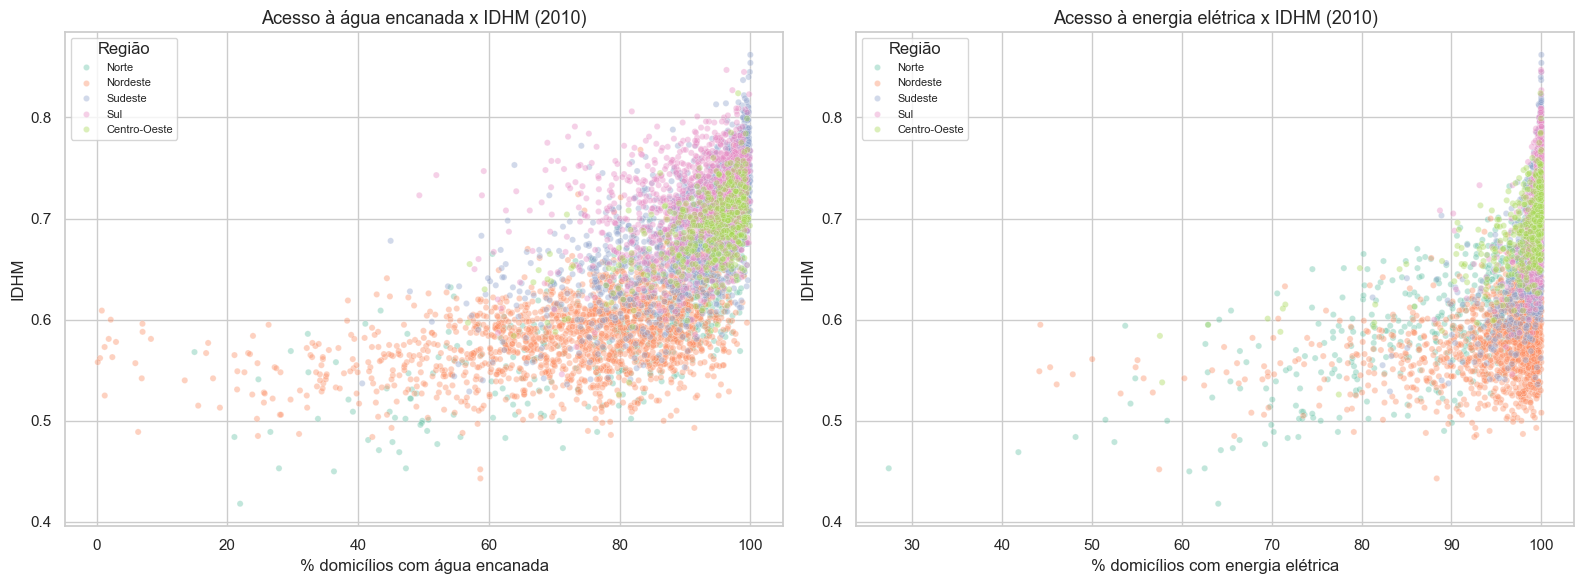


 Correlação entre água encanada e IDHM: 0.659
 Correlação entre energia elétrica e IDHM: 0.490

Interpretação: Municípios com maior acesso à água e energia
tendem a apresentar IDHM mais alto. Infraestrutura básica
é um indicador e um facilitador do desenvolvimento humano.


In [24]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()

    if "taxa_agua_encanada" in df_2010.columns and "taxa_energia_eletrica" in df_2010.columns:

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Gráfico 1: água encanada x IDHM
        sns.scatterplot(
            data=df_2010,
            x="taxa_agua_encanada",
            y="idhm",
            hue="nome_regiao",
            alpha=0.4,
            palette="Set2",
            s=20,
            ax=axes[0]
        )
        axes[0].set_title("Acesso à água encanada x IDHM (2010)", fontsize=13)
        axes[0].set_xlabel("% domicílios com água encanada")
        axes[0].set_ylabel("IDHM")
        axes[0].legend(title="Região", fontsize=8)

        # Gráfico 2: energia elétrica x IDHM
        sns.scatterplot(
            data=df_2010,
            x="taxa_energia_eletrica",
            y="idhm",
            hue="nome_regiao",
            alpha=0.4,
            palette="Set2",
            s=20,
            ax=axes[1]
        )
        axes[1].set_title("Acesso à energia elétrica x IDHM (2010)", fontsize=13)
        axes[1].set_xlabel("% domicílios com energia elétrica")
        axes[1].set_ylabel("IDHM")
        axes[1].legend(title="Região", fontsize=8)

        plt.tight_layout()
        plt.show()

        corr_agua = df_2010[["taxa_agua_encanada", "idhm"]].corr().iloc[0,1]
        corr_energia = df_2010[["taxa_energia_eletrica", "idhm"]].corr().iloc[0,1]
        print(f"\n Correlação entre água encanada e IDHM: {corr_agua:.3f}")
        print(f" Correlação entre energia elétrica e IDHM: {corr_energia:.3f}")
        print()
        print("Interpretação: Municípios com maior acesso à água e energia")
        print("tendem a apresentar IDHM mais alto. Infraestrutura básica")
        print("é um indicador e um facilitador do desenvolvimento humano.")

### 6.5 Mapa de correlações - visão geral das relações

Vamos ver todas as relações de uma vez em um heatmap.


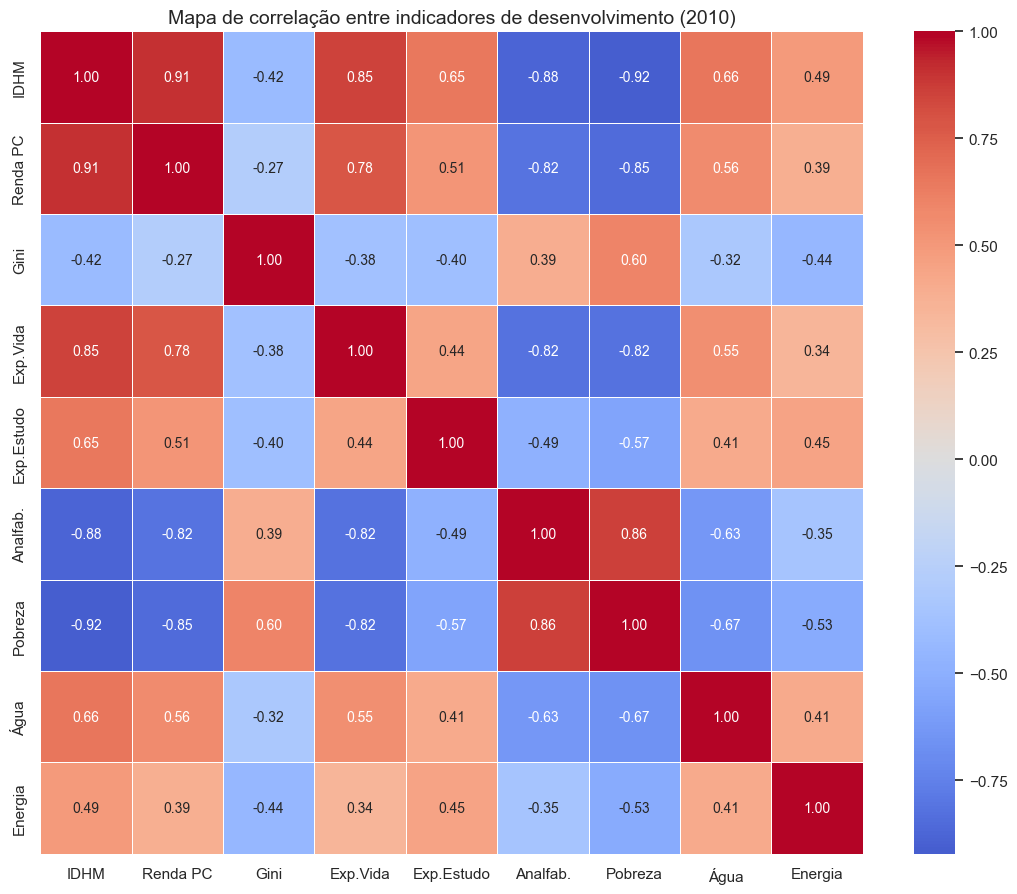


 Principais correlações com o IDHM:
  Pobreza: -0.922 (correlação negativa)
  Renda PC: 0.908 (correlação positiva)
  Analfab.: -0.884 (correlação negativa)
  Exp.Vida: 0.852 (correlação positiva)
  Água: 0.659 (correlação positiva)
  Exp.Estudo: 0.653 (correlação positiva)
  Energia: 0.490 (correlação positiva)
  Gini: -0.424 (correlação negativa)


In [25]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()

    # Seleciona variáveis para o mapa de correlação
    colunas_corr = [c for c in [
        "idhm", "renda_pc", "indice_gini", "expectativa_vida",
        "expectativa_anos_estudo", "taxa_analfabetismo_15_mais",
        "prop_pobreza", "taxa_agua_encanada", "taxa_energia_eletrica"
    ] if c in df_2010.columns]

    # Renomeia para nomes mais curtos no gráfico
    renomear = {
        "idhm": "IDHM",
        "renda_pc": "Renda PC",
        "indice_gini": "Gini",
        "expectativa_vida": "Exp.Vida",
        "expectativa_anos_estudo": "Exp.Estudo",
        "taxa_analfabetismo_15_mais": "Analfab.",
        "prop_pobreza": "Pobreza",
        "taxa_agua_encanada": "Água",
        "taxa_energia_eletrica": "Energia"
    }

    corr_matrix = df_2010[colunas_corr].rename(columns=renomear).corr()

    plt.figure(figsize=(11, 9))

    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        square=True,
        annot_kws={"size": 10}
    )

    plt.title("Mapa de correlação entre indicadores de desenvolvimento (2010)", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n Principais correlações com o IDHM:")
    corr_idhm = corr_matrix["IDHM"].drop("IDHM").sort_values(key=abs, ascending=False)
    for var, val in corr_idhm.items():
        direção = "positiva" if val > 0 else "negativa"
        print(f"  {var}: {val:.3f} (correlação {direção})")

### 6.6 Desigualdades regionais: comparando as regiões do Brasil

Qual é o retrato atual do desenvolvimento humano por região?


In [26]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()

    # Resumo por região
    colunas_resumo = [c for c in [
        "idhm", "renda_pc", "taxa_analfabetismo_15_mais",
        "taxa_agua_encanada", "taxa_energia_eletrica"
    ] if c in df_2010.columns]

    resumo_regiao = df_2010.groupby("nome_regiao")[colunas_resumo].median().round(3)
    resumo_regiao = resumo_regiao.sort_values("idhm", ascending=False)

    print("=== MEDIANA DOS INDICADORES POR REGIÃO (2010) ===")
    print(resumo_regiao.to_string())

=== MEDIANA DOS INDICADORES POR REGIÃO (2010) ===
              idhm  renda_pc  taxa_analfabetismo_15_mais  taxa_agua_encanada  taxa_energia_eletrica
nome_regiao                                                                                        
Sul          0.716   675.025                       7.385              93.760                 99.810
Sudeste      0.705   576.515                       9.335              95.195                 99.820
Centro-Oeste 0.692   571.145                      12.065              95.275                 99.305
Norte        0.609   320.540                      16.580              88.190                 92.200
Nordeste     0.588   259.295                      27.700              78.375                 98.310


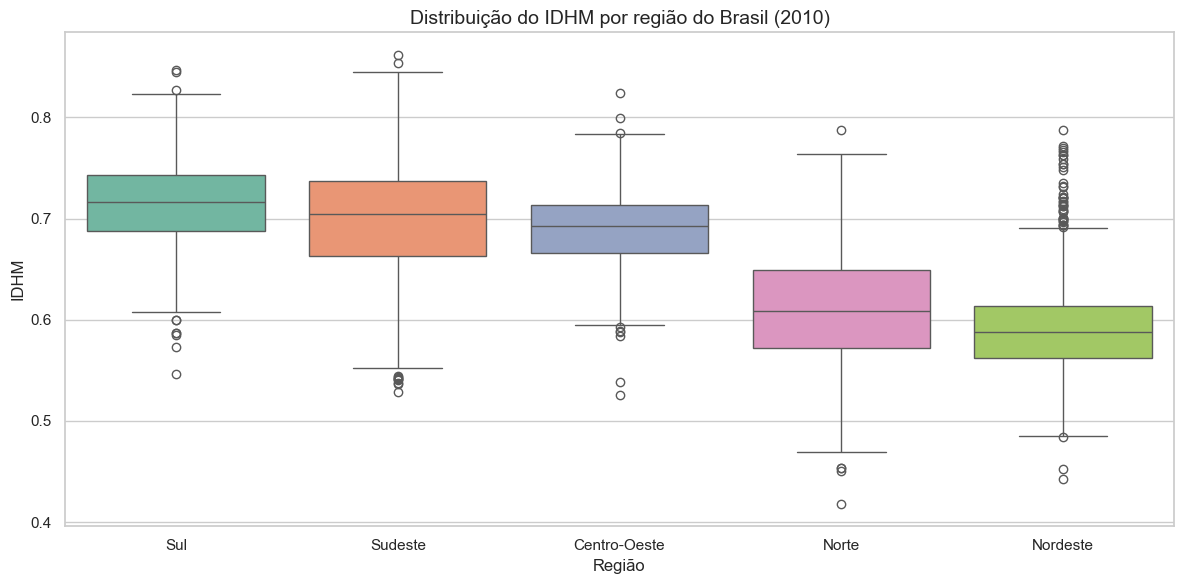


 Interpretação:
Sul e Sudeste lideram o desenvolvimento humano em 2010.
Norte e Nordeste têm as menores medianas, mas com grande variação interna.
Centro-Oeste apresenta posição intermediária.


In [27]:
if df is not None:
    df_2010 = df[df["ano"] == 2010].copy()

    # Boxplot do IDHM por região
    plt.figure(figsize=(12, 6))

    ordem = df_2010.groupby("nome_regiao")["idhm"].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df_2010,
        x="nome_regiao",
        y="idhm",
        palette="Set2",
        order=ordem
    )

    plt.title("Distribuição do IDHM por região do Brasil (2010)", fontsize=14)
    plt.xlabel("Região")
    plt.ylabel("IDHM")
    plt.tight_layout()
    plt.show()

    print("\n Interpretação:")
    print("Sul e Sudeste lideram o desenvolvimento humano em 2010.")
    print("Norte e Nordeste têm as menores medianas, mas com grande variação interna.")
    print("Centro-Oeste apresenta posição intermediária.")

## 7. Storytelling com dados

Agora que temos todas as análises individuais, chegou a hora de **contar uma história** com elas.

Storytelling com dados significa organizar as descobertas em uma narrativa que faz sentido e que guia o leitor de forma lógica até as conclusões.

---

### A História do Desenvolvimento Humano nos Municípios Brasileiros

**Capítulo 1: Um Brasil que avançou - mas de forma desigual**

Entre 1991 e 2010, o Brasil passou por uma transformação expressiva. O IDHM médio dos municípios brasileiros saiu de aproximadamente 0.49 em 1991 para 0.66 em 2010 - um crescimento de quase 35% em apenas duas décadas.

Esse progresso foi real e abrangeu todas as regiões do país. Mas não foi uniforme.

**Capítulo 2: A raiz das desigualdades**

Nossa análise identificou quatro fatores que explicam, em grande parte, as diferenças de desenvolvimento humano entre os municípios:

1. **Educação**: A taxa de analfabetismo apresentou correlação negativa forte com o IDHM (-0.80 a -0.90). Municípios com maior escolaridade da população consistentemente apresentaram maior desenvolvimento.

2. **Renda**: A renda per capita tem correlação positiva forte com o IDHM. Mas a história é mais complexa: municípios com alta renda e alta desigualdade (Gini alto) não necessariamente têm IDHM elevado.

3. **Infraestrutura básica**: O acesso à água encanada e energia elétrica funciona tanto como indicador quanto como impulsionador do desenvolvimento. Municípios sem infraestrutura básica raramente alcançam IDHM acima de 0.6.

4. **Desigualdade**: O índice de Gini mostrou correlação negativa com o IDHM. Alta desigualdade interna prejudica o desenvolvimento, mesmo quando a renda média é alta.

**Capítulo 3: O desafio das regiões**

O mapa das desigualdades regionais no Brasil é claro: Sul e Sudeste lideram o desenvolvimento, com medianas de IDHM próximas a 0.70. Norte e Nordeste enfrentam os maiores desafios, com medianas abaixo de 0.60 em 2010.

Mas há um detalhe importante: o Nordeste apresentou alguns dos maiores *crescimentos proporcionais* do IDHM no período. Isso sugere que os investimentos e políticas públicas da década de 2000 começaram a produzir resultados.

**Capítulo 4: O que os dados nos dizem para o futuro**

Se quisermos acelerar o desenvolvimento humano, os dados apontam um caminho claro:

- Educação básica universal de qualidade (reduzir o analfabetismo)
- Ampliar o acesso à infraestrutura básica nas regiões mais vulneráveis
- Políticas de redução da desigualdade, não apenas de aumento de renda
- Atenção especial aos municípios de pequeno porte nas regiões Norte e Nordeste

## 8. Conclusões

### Respondendo as perguntas norteadoras:

**1. O IDHM melhorou entre 1991 e 2010?**
Sim, significativamente. O IDHM médio cresceu ~35% no período, com todas as regiões apresentando melhora.

**2. Educação influencia o IDHM?**
Fortemente. A correlação entre taxa de analfabetismo e IDHM é negativa e intensa (~-0.85). Este é provavelmente o fator individual de maior impacto.

**3. Renda e desigualdade importam?**
Sim, mas de formas diferentes. Renda per capita alta = tendência de IDHM alto. Mas alta desigualdade (Gini alto) pode neutralizar esse efeito.

**4. Infraestrutura básica faz diferença?**
Absolutamente. Água encanada e energia elétrica apresentam correlação positiva forte com o IDHM. Sem infraestrutura básica, é muito difícil atingir altos índices de desenvolvimento.

**5. Existem desigualdades regionais expressivas?**
Sim. Em 2010, a diferença entre a mediana do IDHM do Sul e do Nordeste ainda era significativa. Mas o Nordeste foi uma das regiões com maior crescimento proporcional.

### Insight principal:
> O desenvolvimento humano no Brasil avançou muito entre 1991 e 2010, mas de forma geograficamente desigual. Educação, infraestrutura e redução da desigualdade são os três pilares que mais diferenciam municípios de alto e baixo IDHM.

## 9. Exercícios

> Os exercícios estão no arquivo `exercicios/` - tente resolver antes de olhar o gabarito!

1. **Evolução estadual**: Selecione 5 estados e plote a evolução do IDHM de 1991 a 2010 em um gráfico de linha. Qual estado mais avançou?

2. **Análise de 1991**: Refaça a análise de correlação mas usando apenas os dados de 1991. As correlações são similares ou diferentes?

3. **Top e Bottom**: Identifique os 10 municípios com maior e menor IDHM em 2010. Eles estão concentrados em alguma região específica?

4. **Pobreza e IDHM**: Crie um scatterplot entre `prop_pobreza` e `idhm` para o ano 2010. O que você observa?

5. **Desafio - Ranking estadual**: Crie um ranking dos estados por IDHM médio em 2010. Visualize com um gráfico de barras horizontais colorido por região.